# Toy DAG demo

Four `Source` artifacts (real Project Gutenberg texts) feeding a `Tokenizer`
trained on three of them, a `TokenizedSource` per source, a `DataSet` for the
run, and one `Pretraining` run on top of it.

Every artifact owns one folder; its files and its `manifest.json` both live
there. Jobs take their inputs from `deps()` -- nothing about "which sources
feed the tokenizer" is declared on the job itself.

Five sections, bottom up: the **plan** (the jobs that would produce a request),
the **manifest** (what an artifact is, written down), **checking and
declaring** a request against a root -- including a run caught mid-write --
**loading** an artifact back from disk, and **visualizing** the result.

In [4]:
import json
from pathlib import Path

from artifact import (
    MANIFEST,
    Artifact,
    DataSet,
    ModelParameters,
    Pretraining,
    PretrainingConfig,
    Source,
    Tokenizer,
)
from resolve import Declaration, job_list, resolve, status
from visualizer import visualize

root = Path("../data_demo")  # kept separate from the real /data tree

In [5]:
odyssey = Source(
    name="odyssey", url="https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
)
mobydick = Source(
    name="mobydick", url="https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
)
romeojuliet = Source(
    name="romeojuliet", url="https://www.gutenberg.org/cache/epub/1513/pg1513.txt"
)
montecristo = Source(
    name="montecristo", url="https://www.gutenberg.org/cache/epub/1184/pg1184.txt"
)

In [6]:
RUN_ID = "toy"

tokenizer = Tokenizer(
    vocab_size=50,
    kind="bpe",
    special_tokens=("<pad>", "<unk>"),
    sources=(odyssey, mobydick, montecristo),
)

training_split = DataSet.from_sources(
    run_id=RUN_ID,
    tokenizer=tokenizer,
    train_sources=[odyssey, mobydick],
    valid_sources=[romeojuliet, montecristo],
)

# model_parameters is architecture; config is everything else about the
# training run -- both change the resulting checkpoint, so both are identity,
# unlike execution-only knobs (device, W&B project name, ...) which never
# reach the artifact at all.
model_parameters = ModelParameters(hidden_size=64, num_layers=2)
config = PretrainingConfig(
    total_steps=2000, batch_size=32, lr=1e-3, seed=1, checkpoint_every=500
)

pretraining = Pretraining(
    run_id=RUN_ID,
    dataset=training_split,
    tokenizer=tokenizer,
    model_parameters=model_parameters,
    config=config,
)

pretraining  # parameters all the way down; `commit` is hidden from the repr

Pretraining(run_id='toy', dataset=DataSet(run_id='toy', train_set=(TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt')), TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'))), valid_set=(Toke

## The plan

`resolve()` sits on top of the artifact tree and attaches the job that produces
each node. It's a pure function of the request: it never looks at the disk,
prunes nothing that already exists, and is never written anywhere.

The plan is what runs; the manifest (next section) is what lands on disk. A plan
node carries a live `Job` the manifest doesn't, and lacks the commit the
manifest has.

## The manifest

Four keys: what it is, the commit its jobs run from, its own parameters, and a
manifest apiece for what it's built from. Nothing derivable is recorded -- no
path, no filenames, no job -- because a recorded derivation is a second answer
that can disagree with the first.

In [ ]:
pretraining.manifest()

## Checking and declaring

`Declaration(artifact, root)` is a request against a root. `.check()` resolves
it and reconciles the whole plan against disk without writing anything --
call it again any time disk state may have changed. `.write()` calls
`.check()` itself, then declares whatever is `new`, and only if nothing is
inconsistent.

Six statuses, dependency-ordered:

| | |
|---|---|
| `new` | nothing there; `write()` will declare it |
| `declared` | manifest agrees, no outputs yet |
| `partial` | manifest agrees, some outputs |
| `done` | manifest agrees, every output present |
| `conflict` | a manifest is there and describes something else |
| `undeclared` | outputs nobody declared |

Only `conflict` and `undeclared` block. Commit drift is reported but allowed,
unless you pass `strict_commit=True`.

In [13]:
# before declaring: the shared artifacts (sources, tokenizer, dataset) are
# already produced and reused as-is; pretraining itself is new
declaration = Declaration(pretraining, root)
print(declaration.check())

run toy under ../data_demo
  declared   sources/odyssey
  declared   sources/mobydick
  declared   sources/montecristo
  declared   tokenizers/bpe-50-2b209d180c
  declared   tokenizers/bpe-50-2b209d180c/bin/odyssey
  declared   tokenizers/bpe-50-2b209d180c/bin/mobydick
  declared   sources/romeojuliet
  declared   tokenizers/bpe-50-2b209d180c/bin/romeojuliet
  declared   tokenizers/bpe-50-2b209d180c/bin/montecristo
  declared   runs/toy/dataset
  declared   runs/toy/pretraining

11 declared
ok -- 0 to declare


In [24]:
# write() checks internally, then writes -- but the Declaration's own rows are
# a snapshot from that internal check, taken just before anything landed, so
# printing `declaration` right after still reads "new". A fresh .check() shows
# what's really on disk now: declared, not yet done.
declaration.write()
# print(declaration.check())

[]

### A run caught mid-write

`Pretraining.files` declares only the final checkpoint and a progress marker
-- the intermediate checkpoints written along the way, at
`config.checkpoint_every`, are undeclared on purpose, and the progress marker
is written last, after the checkpoint is durable, so it can never exist before
the checkpoint does. That ordering is what makes `partial` mean something: a
checkpoint can be there because the process died while writing it, and
`partial` is exactly a manifest that agrees with disk but is still missing a
declared output.

Run the job for real, then take the progress marker back out to stand in for
that interruption -- `check()` catches it without anyone telling it to.

In [26]:
from job import PretrainJob

PretrainJob(pretraining).run(root)
print(Declaration(pretraining, root).check())

FileNotFoundError: [Errno 2] No such file or directory: '../data_demo/runs/toy/dataset/train.bin'

In [27]:
# stand in for a process that died right after the checkpoint landed, before
# the progress marker did
progress = pretraining.paths(root)["progress"]
interrupted = progress.read_text()
progress.unlink()

print(Declaration(pretraining, root).check())

FileNotFoundError: [Errno 2] No such file or directory: '../data_demo/runs/toy/pretraining/progress.json'

In [28]:
# the marker lands, same as it would once the real job actually finishes
progress.write_text(interrupted)
print(Declaration(pretraining, root).check())

NameError: name 'interrupted' is not defined

### Conflicts

Changing parameters means a new run, so a manifest that disagrees with what's
being requested is never a re-declaration -- it means the history recorded
there was edited. `Pretraining`'s path is `runs/{run_id}/pretraining`: it
depends on `run_id` alone, not on `config` or `model_parameters`, so any other
config for the same run lands on the very same folder as `pretraining`, which
is already declared.

In [ ]:
# the realistic version of this mistake: a `toy2` run whose Pretraining was
# copy-pasted from `toy` but still points at `toy`'s dataset. check() only
# reconciles each artifact against disk at its own path -- it doesn't compare
# run ids across the plan, so a dependency stitched in from the wrong run
# reads as clean, not blocked. See spec.md, "Run scope is not checked."
mixed_up = Pretraining(
    run_id="toy2",
    dataset=training_split,  # <- forgot to build a toy2 dataset
    tokenizer=tokenizer,
    model_parameters=ModelParameters(hidden_size=128, num_layers=4),
    config=PretrainingConfig(
        total_steps=1000, batch_size=32, lr=1e-3, seed=2, checkpoint_every=500
    ),
)
print(Declaration(mixed_up, root).check())

## Loading from disk

`Declaration.write()` writes each artifact's manifest into its folder ahead of
the job running. Reading one back gives the artifact itself -- so a
`manifest.json` and the whole definition block above are two spellings of the
same thing, and everything from here on can start from either.

In [31]:
written = (root / pretraining.artifact_path / MANIFEST).read_text()
print(written[:280], "...\n")
print(
    "on disk == what manifest() makes:",
    written == json.dumps(pretraining.manifest(), indent=2),
)

{
  "artifact": "Pretraining",
  "commit": "3ae53695f6ebe7df7198576c316b97f9a9dd9540-dirty",
  "parameters": {
    "config": {
      "batch_size": 32,
      "checkpoint_every": 500,
      "lr": 0.001,
      "seed": 1,
      "total_steps": 2000
    },
    "model_parameters": {
    ...

on disk == what manifest() makes: True


In [34]:
loaded = Artifact.load(root / pretraining.artifact_path / MANIFEST)
loaded == pretraining  # nothing was spelled out -- it all came off the file

True

In [35]:
# a real artifact, so everything derived from it works: where it lives, what
# files it comprises, and the whole tree underneath, typed as what it is.
print(loaded.uid, "->", loaded.artifact_path)
print(sorted(loaded.files))
print(loaded.model_parameters)
print(loaded.config)
print([s.name for s in loaded.tokenizer.sources])

toy-pretraining -> runs/toy/pretraining
['checkpoint', 'progress']
ModelParameters(hidden_size=64, num_layers=2)
PretrainingConfig(total_steps=2000, batch_size=32, lr=0.001, seed=1, checkpoint_every=500)
['odyssey', 'mobydick', 'montecristo']


In [36]:
# and it resolves like anything else -- a plan built from a file, not a notebook
[type(job).__name__ for job in job_list(resolve(loaded))]

['SourceJob',
 'SourceJob',
 'SourceJob',
 'TokenizerJob',
 'TokenizeSourceJob',
 'TokenizeSourceJob',
 'SourceJob',
 'TokenizeSourceJob',
 'TokenizeSourceJob',
 'DataSetJob',
 'PretrainJob']

## Visualizing a plan

`visualize()` draws the same tree `check` reports on: boxes for artifacts,
ellipses for jobs, fill color by type, outline color by status. Shape says what
kind of thing a node is; outline says what the disk says about it -- the two
conventions don't overlap, so a graph stays readable under either question.

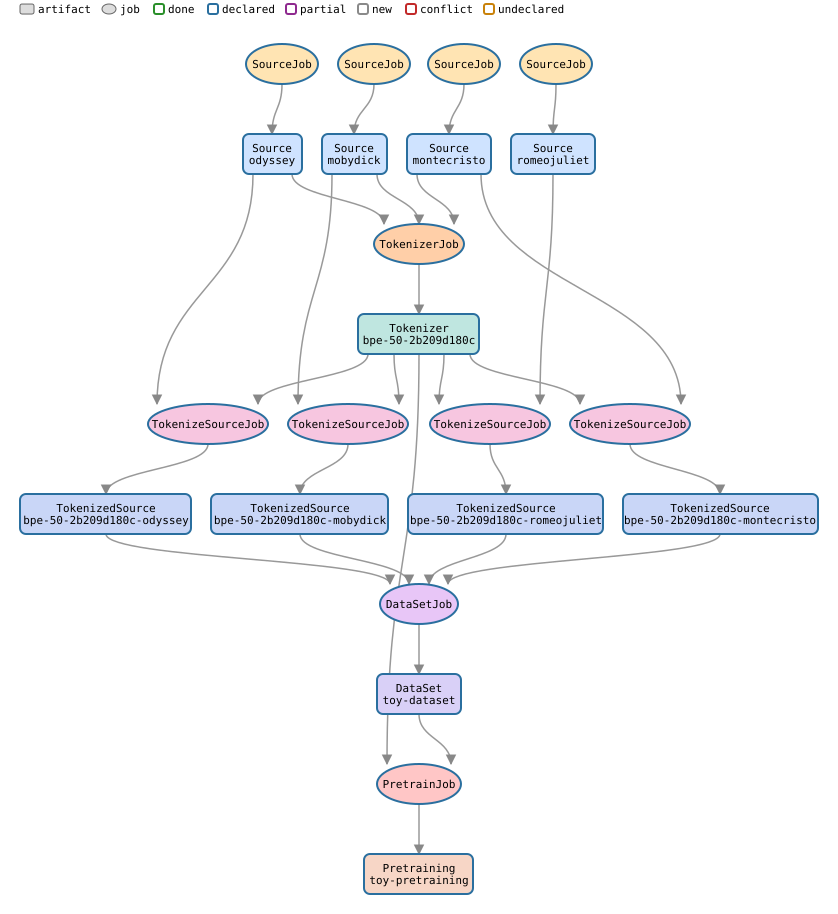

In [37]:
visualize(pretraining_plan, root)  # everything is done, pretraining included

And the conflict from above, drawn: `clash` lands on `pretraining`'s own
folder with a different learning rate, so that one node -- and only that one
node -- comes back red. Its dependencies stay done; nothing about them is in
question.

In [ ]:
visualize(resolve(clash), root)